# Hybrid-electric turboprop

A parallel hybrid: a battery-fed electric motor shares the propeller shaft with the
gas turbine. The cruise battery share is set by the supplied-power ratio `phi`.

In [1]:
import sys, os
# reuse the baseline configs in examples/common.py (works whether the notebook is run
# from trunk/ or from trunk/notebooks/).
for _p in (os.path.join(os.getcwd(), 'examples'), os.path.join(os.getcwd(), '..', 'examples')):
    if os.path.isdir(_p):
        sys.path.insert(0, _p)
import matplotlib.pyplot as plt
import PhlyGreen as pg
from PhlyGreen import postprocess as pp
from common import hybrid_config

## Build the design specification

Raise the cruise `phi` to draw more power from the battery (heavier battery, less fuel).

In [2]:
config = hybrid_config()
for seg in config.mission_stages.segments:
    if seg.name == 'Cruise':
        seg.phi_end = 0.5     # battery supplies up to 50% of cruise power
print('hybrid type:', config.hybrid_type)

hybrid type: Parallel


## Size the aircraft and read the results

In [3]:
aircraft = pg.build_aircraft()
aircraft.configure(config)
r = aircraft.results()
print(f'take-off weight : {r.WTO:8.1f} kg')
print(f'mission fuel    : {r.Wf:8.1f} kg')
print(f'battery mass    : {r.WBat:8.1f} kg')
print(f'battery pack    : {r.pack_energy/3.6e6:6.1f} kWh, {r.pack_power_max/1000:6.1f} kW')

max=58 and min=56
Optimal n 57


max=341 and min=340
Optimal n 341


max=119 and min=118
Optimal n 119


max=125 and min=124
Optimal n 125


max=125 and min=124
Optimal n 125


max=125 and min=124
Optimal n 125


max=125 and min=124
Optimal n 125
take-off weight :  21910.5 kg
mission fuel    :   1572.8 kg
battery mass    :   1686.2 kg
battery pack    :    0.7 kWh, 13563.4 kW


## Plot every outcome (note the battery energy and state-of-charge traces)

For a Class-II battery the state of charge is charge-based: it falls from 1 at the
start of cruise to the minimum SOC by the end of the battery-assisted phase.

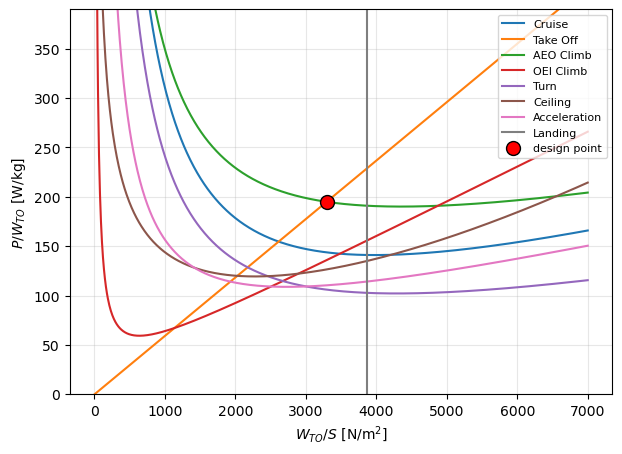

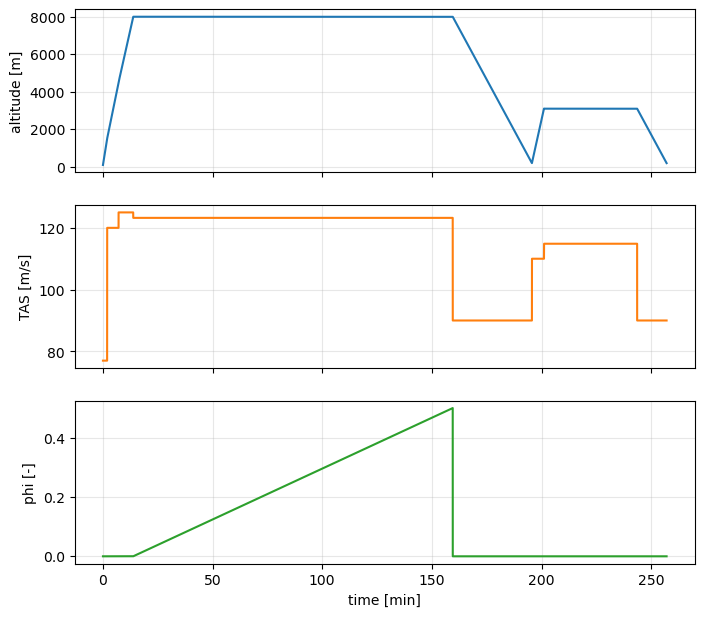

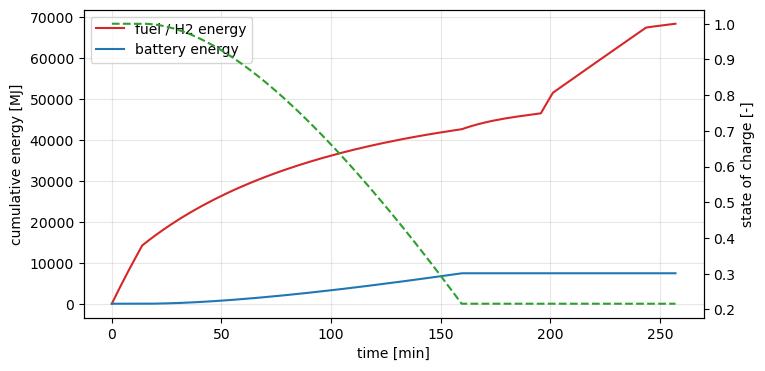

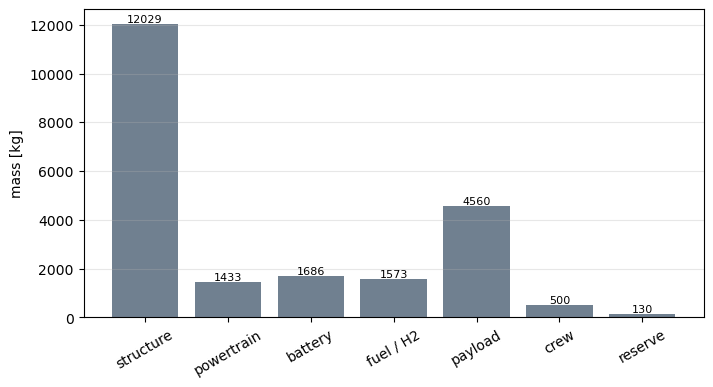

In [4]:
# Every outcome, including the time-resolved ones, via the generic post-processing helpers.
pp.plot_constraint_diagram(aircraft); plt.show()
pp.plot_mission_profile(aircraft);    plt.show()
pp.plot_energy_timeseries(aircraft);  plt.show()
pp.plot_mass_breakdown(aircraft);     plt.show()


## Designing with the Class-II propulsion models

Now we *size the aircraft using the Class-II propulsion models* — the gas-turbine
response surface and the d-q electric motor. These work as a percentage of a **fixed
nominal power** that must be set before the mission (an engine cannot resize itself
instant by instant). A good tentative nominal is `DesignPW * WTO`, taken from a quick
Class-I pre-pass. (We use a simple Class-I battery here to keep the run fast.)

In [5]:
# 1. Class-I pre-pass -> tentative nominal power = DesignPW * WTO
pre = pg.build_aircraft(); pre.configure(hybrid_config(battery_class='I'))
P_nominal = pre.DesignPW * pre.weight.WTO
print(f'tentative nominal power = DesignPW * WTO = {P_nominal/1e3:.0f} kW')

tentative nominal power = DesignPW * WTO = 4297 kW


In [6]:
# 2. Hybrid sized WITH the Class-II gas turbine + electric motor
cfg = hybrid_config(battery_class='I')
for seg in cfg.mission_stages.segments:
    if seg.name == 'Cruise':
        seg.phi_end = 0.5
cfg.energy.eta_gas_turbine_model = 'ResponseSurface'
cfg.energy.gt_design_power = P_nominal
cfg.energy.eta_electric_motor_model = 'Smart'
cfg.energy.em_design_power = P_nominal
cfg.energy.em_design_voltage = 800.0
cfg.energy.em_design_rpm = 11000.0
aircraft = pg.build_aircraft()
aircraft.configure(cfg)
r = aircraft.results()
print(f'take-off weight : {r.WTO:8.1f} kg')

take-off weight :  19657.8 kg


## Was the nominal power adequate?

After sizing, compare the nominal power against the peak power actually absorbed.

In [7]:
for name, info in aircraft.powertrain.report_class_ii_sizing().items():
    print(f"{name:14s}: nominal {info['nominal']/1e3:7.0f} kW, peak "
          f"{info['actual']/1e3:7.0f} kW -> {info['status']} (ratio {info['ratio']:.2f})")

gas turbine   : nominal    4297 kW, peak    3658 kW -> ok (ratio 0.85)
electric motor: nominal    4297 kW, peak    1070 kW -> oversized (ratio 0.25)


## Class-II propulsion time series

Because the gas turbine was actually sized (with its fixed nominal power), the
throttle is now a realistic, varying result — high on climb, lower in cruise where the
battery offloads the turbine — not pinned at 100%. The plot also shows each
component's efficiency and the propeller pitch. (The nominal powers and engine count
are taken from the designed aircraft.)

Loading surrogate data from: /Users/riccardo/Distributions/PhlyGreen/trunk/PhlyGreen/Systems/Powertrain/data/propeller_data_rbf.csv ...
⚠️ DETECTED WATTS IN CSV. Converting to kW...
----------------------------------------
CSV DATA RANGE (Converted):
Power: 50 - 2500 kW
Speed: 10 - 180 m/s
----------------------------------------
Training Pitch Solver (Governor)...
Training Efficiency Model...
Surrogate models ready.



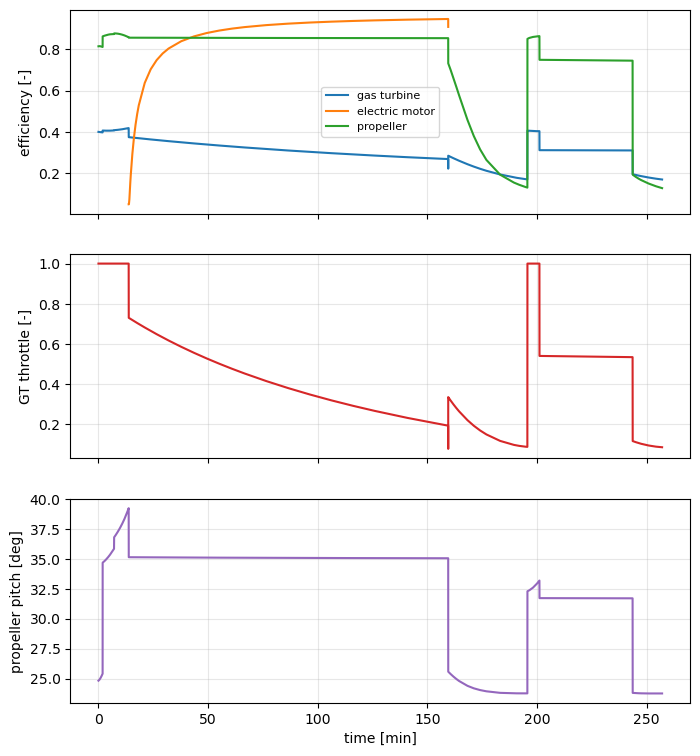

In [8]:
pp.plot_component_timeseries(aircraft); plt.show()